# A normal operator from a trajectory

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/scalar.ipynb)

`scalar_kernel`: the Gram of a non-Cartesian encoding as two FFTs and a
multiply, checked against the NUFFT pair it replaces, and then driven in a
conjugate-gradient solve.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n = 128
image = torch.as_tensor(phantom(n)).to(torch.complex64)

# Golden-angle radial, in normalized k-space: -0.5 is grid location -kN/2 of a
# grid of size kN, so the same numbers describe the image grid and the doubled
# one the transfer lives on.
n_spokes, n_samples = 201, 256
angles = np.pi * (np.arange(n_spokes) * (np.sqrt(5) - 1) / 2 % 1.0)
radius = np.linspace(-0.5, 0.5, n_samples, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)
print(f"trajectory {trajectory.shape} (shots, points, axes)")

trajectory (201, 256, 2) (shots, points, axes)


## Building the transfer

`A^H A` for a non-Cartesian encoding is a convolution, so it can be applied as
a pointwise multiply between two FFTs instead of a forward and adjoint NUFFT.
The convolution kernel lives on a grid twice the image in every dimension --
a point spread function on `N` covers displacements to `±N/2`, and the Gram
needs `±(N-1)`.

That doubling is the cost this package is about. The transfer is stored only
where the scan put weight, and filed by coordinate parity, so the doubled grid
is never materialised.

In [3]:
kernel = mt.scalar_kernel(trajectory, (n, n))
print(kernel)
print(f"rank {kernel.rank}, image {kernel.image_shape}, transfer on {kernel.spatial_shape}")
print(f"stored {kernel.storage_nbytes / 2**20:.2f} MiB of a dense "
      f"{kernel.dense_nbytes / 2**20:.2f} MiB, {kernel.compression_ratio:.2f}x")

PolyphaseToeplitzKernel(rank=1, image_shape=(128, 128), components=4, compression=1.19x)
rank 1, image (128, 128), transfer on (256, 256)
stored 0.42 MiB of a dense 0.50 MiB, 1.19x


## Is it the Gram?

The only evidence that counts is `kernel(x)` against `A_adjoint(A(x))` on a
real trajectory. The reference below is raw FINUFFT — nothing in it comes from
the package, so agreement is evidence rather than self-consistency.

In [4]:
import finufft


def exact_gram(x):
    """``A^H A x`` with raw FINUFFT: nothing here comes from the package.

    ``A`` is a type-2 transform with isign=-1 and ``A^H`` a type-1 with
    isign=+1 -- the unnormalised adjoint pair -- divided by the size of the
    doubled grid the convolution runs on, which is the whole normalization.
    """
    points = np.ascontiguousarray(
        trajectory.reshape(-1, 2).astype(np.float64) * 2 * np.pi
    )
    columns = [np.ascontiguousarray(points[:, axis]) for axis in range(2)]
    forward = finufft.Plan(2, (n, n), isign=-1, eps=1e-9, dtype="complex128")
    forward.setpts(*columns)
    adjoint = finufft.Plan(1, (n, n), isign=+1, eps=1e-9, dtype="complex128")
    adjoint.setpts(*columns)
    gridded = adjoint.execute(forward.execute(np.asarray(x, dtype=np.complex128)))
    return gridded / (2 * n) ** 2


truth = exact_gram(image.numpy())
fast = kernel(image[None, None])[0, 0].numpy()

error = np.linalg.norm(fast - truth) / np.linalg.norm(truth)
print(f"relative error against the exact Gram: {error:.2e}")

relative error against the exact Gram: 9.32e-06


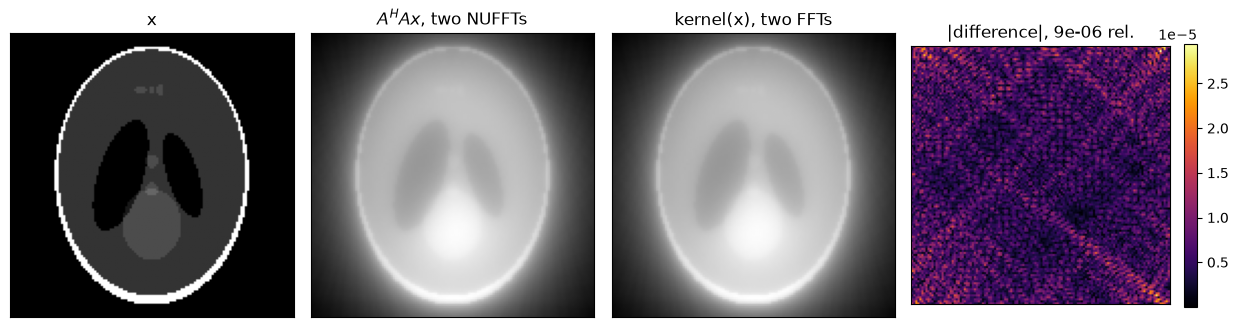

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
axes[0].imshow(np.abs(image.numpy()), cmap="gray")
axes[0].set_title("x")
axes[1].imshow(np.abs(truth), cmap="gray")
axes[1].set_title("$A^H A x$, two NUFFTs")
axes[2].imshow(np.abs(fast), cmap="gray")
axes[2].set_title("kernel(x), two FFTs")
for axis in axes[:3]:
    axis.set_xticks([])
    axis.set_yticks([])
shown = axes[3].imshow(np.abs(fast - truth) / np.abs(truth).max(), cmap="inferno")
axes[3].set_title(f"|difference|, {error:.0e} rel.")
axes[3].set_xticks([])
axes[3].set_yticks([])
fig.colorbar(shown, ax=axes[3], fraction=0.046)
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "scalar.png", dpi=110, bbox_inches="tight")

## What it buys

The transfer is built once and applied every iteration, so what matters is
the per-application cost against the NUFFT pair it replaces.

In [7]:
def time_it(call, repeats=5):
    call()
    start = perf_counter()
    for _ in range(repeats):
        call()
    return (perf_counter() - start) / repeats


batched = image[None, None]
nufft_time = time_it(lambda: exact_gram(image.numpy()), repeats=3)
kernel_time = time_it(lambda: kernel(batched))
build_time = time_it(lambda: mt.scalar_kernel(trajectory, (n, n)), repeats=2)

print(f"two NUFFTs  {1e3 * nufft_time:7.1f} ms per application")
print(f"the kernel  {1e3 * kernel_time:7.1f} ms per application  "
      f"({nufft_time / kernel_time:.0f}x)")
print(f"the build   {1e3 * build_time:7.1f} ms, paid once")
print()
# Break-even is the build divided by what each application saves, not by the
# ratio between them.
applications = build_time / (nufft_time - kernel_time)
print(f"break-even after {applications:.1f} applications")

two NUFFTs     40.1 ms per application
the kernel      2.6 ms per application  (16x)
the build      12.3 ms, paid once

break-even after 0.3 applications


## In a solve

The normal operator is the whole of what CG needs: it never sees the
trajectory, only `x -> A^H A x`. Below is plain CG with a little Tikhonov
damping, driven by the kernel.

What is left at convergence is not the solver's doing. The object has edges
the trajectory does not sample, so no solve recovers them; the residual falls
by four decades while the error against the object stops at what the sampling
supports.

In [8]:
def conjugate_gradient(normal, rhs, iterations=30, damping=1e-3):
    """Plain CG on ``(N + damping I) x = rhs``, to show the normal in use."""
    x = torch.zeros_like(rhs)
    r = rhs.clone()
    p = r.clone()
    residuals = []
    for _ in range(iterations):
        q = normal(p) + damping * p
        alpha = (r.conj() * r).sum() / (p.conj() * q).sum()
        x = x + alpha * p
        r_next = r - alpha * q
        beta = (r_next.conj() * r_next).sum() / (r.conj() * r).sum()
        p = r_next + beta * p
        r = r_next
        residuals.append(float(r.norm() / rhs.norm()))
    return x, residuals


# The right-hand side of a CG-SENSE solve is the adjoint of the measurement.
# With no coils and no noise that is the Gram of the object, which is also the
# one-step gridding image the solve starts from.
adjoint_image = kernel(image[None, None])
estimate, residuals = conjugate_gradient(kernel, adjoint_image)


def matched(estimate):
    """Scale out the constant CG does not see, and measure what is left."""
    got, want = estimate.reshape(-1), image.numpy().reshape(-1)
    scale = np.vdot(got, want) / np.vdot(got, got)
    return scale * estimate, float(
        np.linalg.norm(scale * got - want) / np.linalg.norm(want)
    )


gridded, gridded_error = matched(adjoint_image[0, 0].numpy())
solved, solved_error = matched(estimate[0, 0].numpy())
print(f"one-step gridding {gridded_error:.3f}, after {len(residuals)} CG iterations {solved_error:.3f}")
print(f"residual fell to {residuals[-1]:.1e}")

one-step gridding 0.790, after 30 CG iterations 0.122
residual fell to 2.3e-04


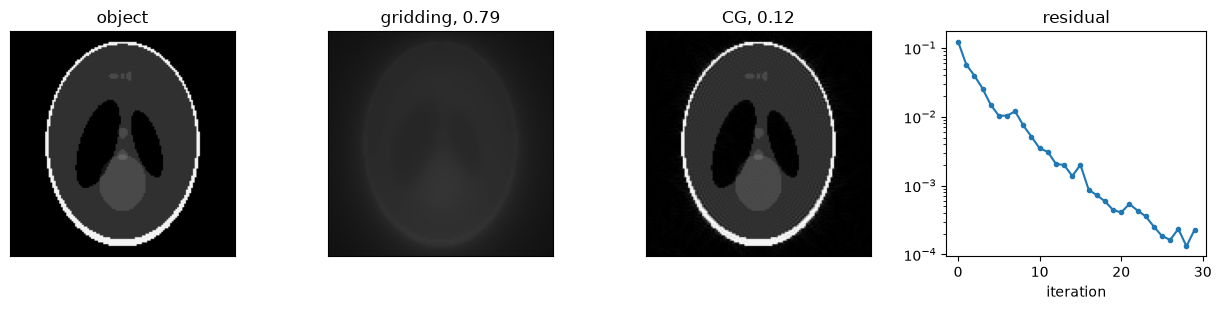

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
for axis, data, title in (
    (axes[0], image.numpy(), "object"),
    (axes[1], gridded, f"gridding, {gridded_error:.2f}"),
    (axes[2], solved, f"CG, {solved_error:.2f}"),
):
    axis.imshow(np.abs(data), cmap="gray", vmin=0, vmax=1.05)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
axes[3].semilogy(residuals, "o-", markersize=3)
axes[3].set_title("residual")
axes[3].set_xlabel("iteration")
fig.tight_layout()